unknown

# 0. Introduction

## Theme: Crop Production by District

# 1. Data Collection

## Importing Libraries

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import requests

## Importing Datasets from Google Drive

There are two datasets in this project, which are:
*   Dataset 1: crops_district_production.csv
*   Dataset 2: environmental_data_by_district_2017.csv

## Filtering Dataset

In district_coords.csv, all districts have more than one coordinates. Therefore, the dataset is filtered and left with one coordinate only in order to minimize the running time of generating the weather dataset.

In [7]:
# Load your dataset
df = pd.read_csv("C:\\Users\\CHONG DER YUNG\\year1sem2\\ml\\datasets\\district_coords.csv", encoding='latin-1')
df.columns = df.columns.str.strip().str.lower()  # Clean column names

# Round latlon to standardize
df['lat'] = df['lat'].round(5)
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')
df['lon'] = df['lon'].round(5)

# Keep only the first occurrence of each district
unique_districts = df.drop_duplicates(subset='district', keep='first')

# Save filtered result (optional)
unique_districts.to_csv("C:\\Users\\CHONG DER YUNG\\year1sem2\\ml\\datasets\\district_coords.csv", index=False)

# Show result
print(f"Filtered to {len(unique_districts)} unique districts.")

Filtered to 144 unique districts.


In [10]:
# Load dataset
df = pd.read_csv(r"C:\Users\CHONG DER YUNG\year1sem2\ml\datasets\district_coords.csv")
df.columns = df.columns.str.strip().str.lower()

# Drop duplicates and round lat/lon to 2 decimals which required by NASA POWER API
df = df.drop_duplicates(subset=['lat', 'lon']).reset_index(drop=True)
df['lat'] = df['lat'].round(2)
df['lon'] = df['lon'].round(2)

# Define parameters to fetch
params_map = {
    'temperature': 'T2M',
    'precipitation': 'PRECTOTCORR',
    'humidity': 'RH2M',
    'wind_speed': 'WS2M',
    'surface_soil_wetness': 'GWETTOP',
    'solar_radiation': 'ALLSKY_SFC_SW_DWN',
    'atmospheric_prssure' : 'PSC'
}

# Add columns to dataframe
for col in params_map:
    df[col] = None

# Track success
all_successful = True

# Loop over each unique location to fetch data
for idx, row in df.iterrows():
    lat = row['lat']
    lon = row['lon']

    url = "https://power.larc.nasa.gov/api/temporal/daily/point"
    params = {
        "parameters": ",".join(params_map.values()),
        "community": "AG",
        "longitude": lon,
        "latitude": lat,
        "start": "20170101",
        "end": "20170101",
        "format": "JSON"
    }

    try:
        response = requests.get(url, params=params)
        if response.status_code == 200:
            data = response.json()["properties"]["parameter"]
            for col, param in params_map.items():
                df.at[idx, col] = data[param]["20170101"]
        else:
            all_successful = False
    except Exception:
        all_successful = False

    time.sleep(1)

# Save final results
df.to_csv(r"C:\Users\CHONG DER YUNG\year1sem2\ml\datasets\district_weather_20170101.csv", index=False)

# Print summary
if all_successful:
    print("Weather data successfully retrieved for all locations.")
else:
    print("Weather data retrieval completed, but some locations failed.")

Weather data retrieval completed, but some locations failed.


In [11]:
# Load the crop production dataset
crops_df = pd.read_csv(r"C:\Users\CHONG DER YUNG\year1sem2\ml\datasets\crops_district_production.csv")

# Load the environmental dataset
env_df = pd.read_csv(r"C:\Users\CHONG DER YUNG\year1sem2\ml\datasets\district_weather_20170101.csv")

## Exploring Datasets

Load and review both datasets to gain a quick overview of the raw data.

Dataset 1: crops_district_production.csv

In [12]:
# Check the first few rows of first dataset
crops_df.head()

,date,state,district,crop_type,crop_species,production
0,2017-01-01,Johor,Batu Pahat,cash_crops,cassava,920.5
1,2017-01-01,Johor,Batu Pahat,cash_crops,groundnuts,0.0
2,2017-01-01,Johor,Batu Pahat,cash_crops,sweet_corn,0.0
3,2017-01-01,Johor,Batu Pahat,cash_crops,sweet_potato,350.0
4,2017-01-01,Johor,Batu Pahat,cash_crops,yam,395.4


Evaluate the sufficiency of features, examples and samples in this dataset.

In [13]:
# Visualize info such as data types and numbers of missing data
crops_df.info()

# Obtain the decriptive statistic of the dataset (mean, standard deviation, quartiles, etc.)
crops_df.describe().transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11002 entries, 0 to 11001
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          11002 non-null  object 
 1   state         11002 non-null  object 
 2   district      11002 non-null  object 
 3   crop_type     11002 non-null  object 
 4   crop_species  11002 non-null  object 
 5   production    11002 non-null  float64
dtypes: float64(1), object(5)
memory usage: 515.8+ KB


,count,mean,std,min,25%,50%,75%,max
production,11002.0,315.854812,3368.437864,0.0,0.0,0.0,45.5975,175141.75


This dataset contains 11,002 entries with 6 columns detailing crop production by district and crop type in Malaysia. The main features are state, district, crop_type, crop_species, and date, with production as the target variable. Production values vary widely, indicating significant differences across regions and crops. The dataset has no missing values and is ready for analysis.

Dataset 2: environmental_data_by_district_2017.csv

In [14]:
# Check the first few rows of second dataset
env_df.head()

,states,district,town,lat,lon,temperature,precipitation,humidity,wind_speed,surface_soil_wetness,solar_radiation,atmospheric_prssure
0,Johor,Batu Pahat,Batu Pahat,1.95,102.86,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Johor,Johor Bahru,Johor Bahru,1.50,103.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Johor,Kluang,Kluang,1.99,103.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Johor,Kota Tinggi,Kota Tinggi,1.71,103.90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Johor,Kulai,Kulai,1.65,103.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Evaluate the sufficiency of features, examples and samples in this dataset.

In [15]:
# Visualize info such as data types and numbers of missing data
env_df.info()

# Obtain the decriptive statistic of the dataset (mean, standard deviation, quartiles, etc.)
env_df.describe().transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   states                144 non-null    object 
 1   district              144 non-null    object 
 2   town                  144 non-null    object 
 3   lat                   144 non-null    float64
 4   lon                   144 non-null    float64
 5   temperature           0 non-null      float64
 6   precipitation         0 non-null      float64
 7   humidity              0 non-null      float64
 8   wind_speed            0 non-null      float64
 9   surface_soil_wetness  0 non-null      float64
 10  solar_radiation       0 non-null      float64
 11  atmospheric_prssure   0 non-null      float64
dtypes: float64(9), object(3)
memory usage: 13.6+ KB


,count,mean,std,min,25%,50%,75%,max
lat,144.0,4.005208,1.666896,1.09,2.5725,4.11,5.4575,6.78
lon,144.0,105.906806,5.913744,99.79,101.4575,102.51,111.6425,118.54
temperature,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
precipitation,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
humidity,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wind_speed,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
surface_soil_wetness,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
solar_radiation,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
atmospheric_prssure,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


This dataset contains 1448 entries with 5 columns detailing geographical locations. The columns include 'States', 'District', and 'Town' which are stored as text data, and 'Lat' (Latitude) as numerical data. The 'Lon' (Longitude) column is currently stored as text, which might need conversion if numerical operations are required. The dataset is complete with no missing values across all columns.



# 2. Data Preprocessing

## Data Cleaning

### Find Missing Value


In [16]:
# Obtain the total number of missing values per column
crops_df.isna().sum()

date            0
state           0
district        0
crop_type       0
crop_species    0
production      0
dtype: int64

In [17]:
# Obtain the total number of missing values per column
env_df.isna().sum()

states                    0
district                  0
town                      0
lat                       0
lon                       0
temperature             144
precipitation           144
humidity                144
wind_speed              144
surface_soil_wetness    144
solar_radiation         144
atmospheric_prssure     144
dtype: int64

**Summary**

Dataset 1 (crops_df) has no missing values. Dataset 2 (env_df) also has no missing values after fetching environmental data. Both datasets are complete regarding missing entries in their respective columns.

### Checking Duplicate Rows

In [18]:
# Find duplicate rows
crops_duplicate_rows = crops_df[crops_df.duplicated(keep='first')]
crops_duplicate_rows.info()

<class 'pandas.core.frame.DataFrame'>
Index: 117 entries, 857 to 9480
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          117 non-null    object 
 1   state         117 non-null    object 
 2   district      117 non-null    object 
 3   crop_type     117 non-null    object 
 4   crop_species  117 non-null    object 
 5   production    117 non-null    float64
dtypes: float64(1), object(5)
memory usage: 6.4+ KB


"This output confirms that 117 duplicate rows were found in the crops_df DataFrame(Dataset 1), all with complete data."

In [19]:
# Check for exact duplicate rows
crops_duplicates_count = crops_df.duplicated().sum()
print(f"Total duplicate rows: {crops_duplicates_count}")

Total duplicate rows: 117


The check for duplicate rows found 117 duplicate entries, which will be removed to ensure data integrity.

In [20]:
# Find duplicate rows
env_duplicate_rows = env_df[env_df.duplicated(keep='first')]
env_duplicate_rows.info()

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   states                0 non-null      object 
 1   district              0 non-null      object 
 2   town                  0 non-null      object 
 3   lat                   0 non-null      float64
 4   lon                   0 non-null      float64
 5   temperature           0 non-null      float64
 6   precipitation         0 non-null      float64
 7   humidity              0 non-null      float64
 8   wind_speed            0 non-null      float64
 9   surface_soil_wetness  0 non-null      float64
 10  solar_radiation       0 non-null      float64
 11  atmospheric_prssure   0 non-null      float64
dtypes: float64(9), object(3)
memory usage: 0.0+ bytes


There are no duplicates rows on env_df dataframe which is dataset 2

### Dropping Duplicate Rows

In [21]:
# Drop duplicate rows and keep the first occurrence
crops_df_cleaned = crops_df.drop_duplicates(keep='first')

# Check the new shape after removing duplicates
print(f"Shape after removing duplicates: {crops_df_cleaned.shape}")

Shape after removing duplicates: (10885, 6)


After removing the 117 duplicate rows from crops_df(dataset 1), the cleaned dataframe crops_df_cleaned now has 10885 rows and 6 columns."

### Addressing Outliers

The boxplots are visualised to find the outliers of all the features.

From the boxplots above, we can see that there is only one feature has outliers, hence outliers need to be removed before applying normalization on these three columns.

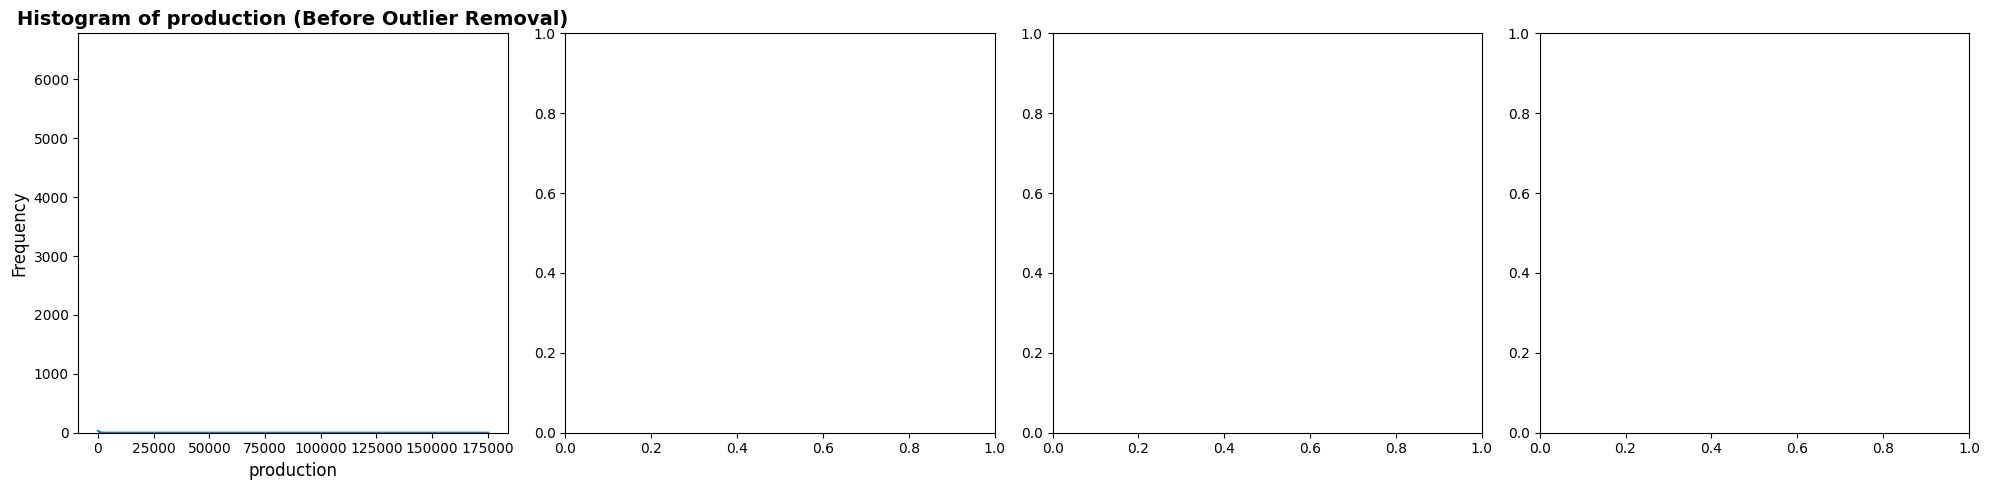


Min and Max values before outlier removal:
  'production': min = 0.0, max = 175141.75


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to plot
columns_to_clean = ['production']

# Plot before removing outliers
n_cols = 4
n_rows = (len(columns_to_clean) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 5))

if n_rows * n_cols == 1:
    axes = [axes]
elif n_rows > 1 or n_cols > 1:
    axes = axes.flatten()

for i, col in enumerate(columns_to_clean):
    if i < len(axes) and col in crops_df.columns:
        ax = axes[i]
        sns.histplot(data=crops_df, x=col, kde=True, ax=ax)
        ax.set_title(f'Histogram of {col} (Before Outlier Removal)', fontsize=14, weight='bold')
        ax.set_xlabel(col, fontsize=12)
        ax.set_ylabel('Frequency', fontsize=12)
    elif i < len(axes):
        axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# Print min and max values before removal
print("\nMin and Max values before outlier removal:")
for col in columns_to_clean:
    if col in crops_df.columns:
        print(f"  '{col}': min = {crops_df[col].min()}, max = {crops_df[col].max()}")

After removing the outliers, we need to confirm it by visualizing the features with histograms and reading the lower and upper bounds after outlier removal.

Data Prepartion - copy original data

In [9]:
# Make a copy of the original data to preserve it
crops_df_min_max = crops_df.copy()

Visualize Boxplot & Histogram Before Outlier Removal

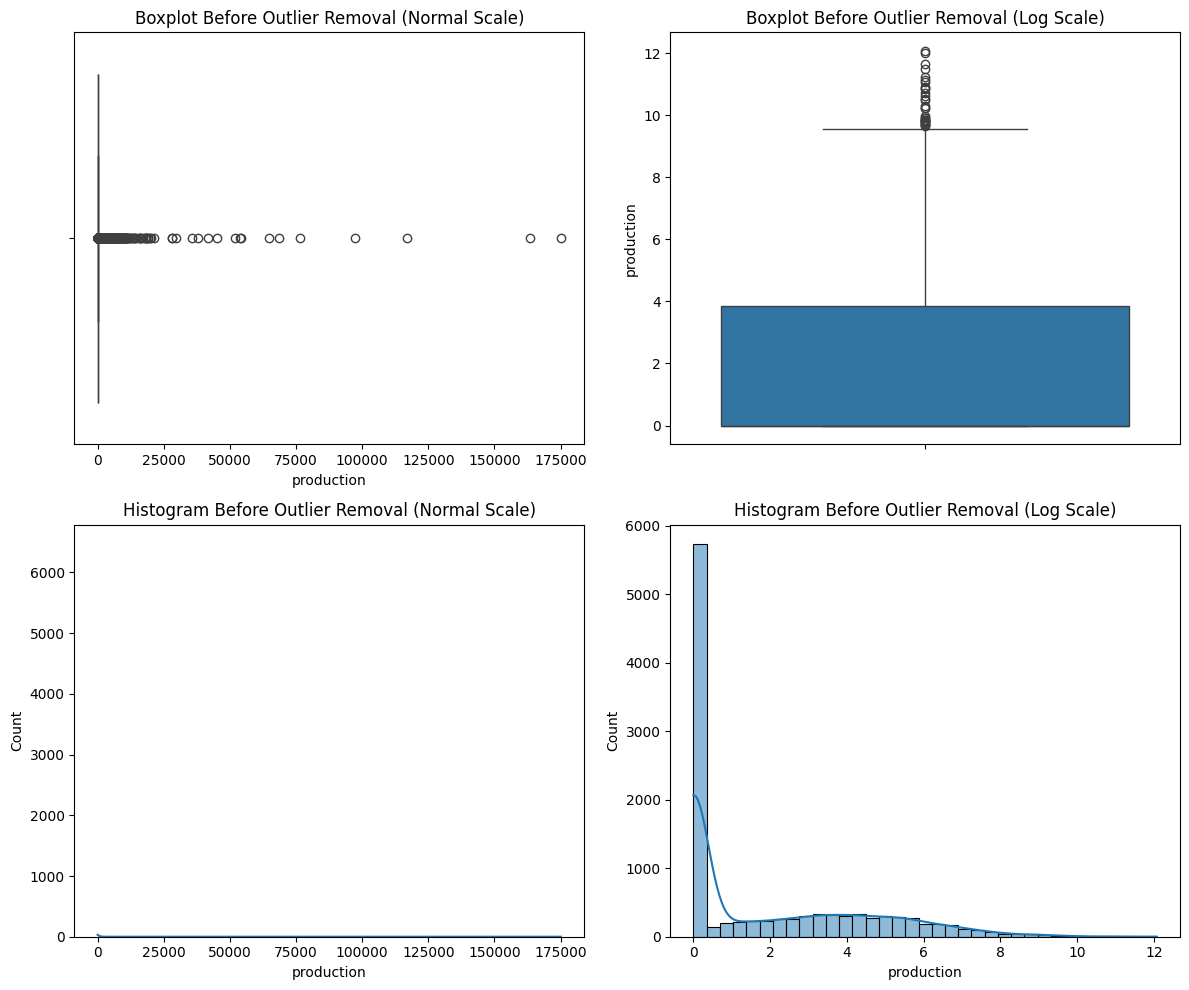

Min and Max values before outlier removal:
  'production': min = 0.0, max = 175141.75


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

columns_to_clean = ['production']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # 2 rows, 2 columns
axes = axes.flatten()

# Boxplot (Normal scale)
sns.boxplot(data=crops_df, x='production', ax=axes[0])
axes[0].set_title("Boxplot Before Outlier Removal (Normal Scale)")

# Boxplot (Log scale)
sns.boxplot(data=np.log1p(crops_df['production']), ax=axes[1]) # add 1 to avoid log(0)
axes[1].set_title("Boxplot Before Outlier Removal (Log Scale)")

# Histogram (Normal scale)
sns.histplot(data=crops_df, x='production', kde=True, ax=axes[2])
axes[2].set_title("Histogram Before Outlier Removal (Normal Scale)")

# Histogram (Log scale)
sns.histplot(np.log1p(crops_df['production']), kde=True, ax=axes[3])
axes[3].set_title("Histogram Before Outlier Removal (Log Scale)")

plt.tight_layout()
plt.show()

# Summary statistics
for col in columns_to_clean:
    print(f"Min and Max values before outlier removal:\n  '{col}': min = {crops_df[col].min()}, max = {crops_df[col].max()}")

The boxplot and histogram clearly show that crop production data is highly skewed, with many values near zero and a few extremely large values. This indicates significant outliers that need to be addressed before further analysis.

Remove Outliers using IQR

In [ ]:
numeric_cols = crops_df_min_max.select_dtypes(include=[np.number]).columns.tolist()
outlier_cols = [col for col in ['production', 'temperature', 'precipitation', 'humidity', 'wind_speed'] 
                   if col in numeric_cols]
    
print(f"   Checking outliers in: {outlier_cols}")

# Remove extreme outliers (top/bottom 2.5%)
for col in outlier_cols:
    Q1 = crops_df_min_max[col].quantile(0.025)
    Q99 = crops_df_min_max[col].quantile(0.975)
    df_clean = crops_df_min_max[(df_clean[col] >= Q1) & (df_clean[col] <= Q99)]

print(f"   Removed outliers: {len(df)} → {len(crops_df_min_max)} samples ({len(crops_df_min_max)/len(crops_df)*100:.1f}% retained)")

In [19]:
# IQR method for outlier removal
Q1 = crops_df_min_max[columns_to_clean].quantile(0.25)
Q3 = crops_df_min_max[columns_to_clean].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

for col in columns_to_clean:
    crops_df_min_max = crops_df_min_max[(crops_df_min_max[col] >= lower_bound[col]) &
                                        (crops_df_min_max[col] <= upper_bound[col])]

# print shape
print(f"\nShape after removing outliers: {crops_df_min_max.shape}")


Shape after removing outliers: (9062, 6)


The boxplot and histogram on a normal scale show that the IQR method effectively removes extreme values, resulting in a more compact boxplot with reduced range and fewer outliers. The histogram reflects a more representative distribution of typical production values. The maximum production value is significantly reduced, preventing outlier dominance in analysis.

Visualize Boxplot & Histogram After Outlier Removal

The normal scale is useful for showing absolute values, but when there is high skewness or large numerical gaps, the graph becomes difficult to interpret, especially for smaller values.


## Datasets Merging

This code merges crop production data with environmental data to study how weather and soil factors impact agricultural yields. It first standardizes text columns by removing extra spaces and converting text to lowercase to ensure proper matching. It then removes duplicates from the environmental data and filters it to only include districts present in the crop data. Finally, it performs an inner join on state and district to create a clean, combined dataset.

In [20]:
# Standardize location columns (remove spaces and make lowercase)
crops_df['state'] = crops_df['state'].str.strip().str.lower()
crops_df['district'] = crops_df['district'].str.strip().str.lower()
env_df['states'] = env_df['states'].str.strip().str.lower()
env_df['district'] = env_df['district'].str.strip().str.lower()

# Remove duplicate state-district entries from environmental data
env_df_latest = env_df.drop_duplicates(subset=['states', 'district'], keep='last')

# Extract unique such as state, district and combinations from crop data
crops_unique_locations = crops_df[['state', 'district']].drop_duplicates().rename(
    columns={'state': 'states'}
)

# Filter environmental data to keep only locations that exist in crop data
env_filtered = pd.merge(
    crops_unique_locations,
    env_df_latest,
    on=['states', 'district'],
    how='inner'  # Keep only matching locations
)

In [52]:
# Merge crop data with filtered environmental data
merged_df = pd.merge(
    crops_df,
    env_filtered,
    left_on=['state', 'district'],
    right_on=['states', 'district'],
    how='inner'  # Keep only rows that match in both datasets
)

# Drop duplicated or unnecessary columns after merge
merged_df.drop(columns=['states', 'district'], inplace=True)

# Display shape information to verify
print("Shape of original crops_df:", crops_df.shape)
print("Shape of original env_df:", env_df.shape)
print("Shape after removing duplicates from env_df (env_df_latest):", env_df_latest.shape)
print("Shape of filtered environmental data (env_filtered):", env_filtered.shape)
print("Shape of final merged DataFrame (merged_df):", merged_df.shape)

# Check for missing values
print("\nMissing values in merged_df:\n", merged_df.isna().sum())

# Preview the merged data
print("\nPreview of merged_df:\n", merged_df.head())

df.to_csv(r"C:\Users\CHONG DER YUNG\year1sem2\ml\datasets\merged_data.csv", index=False)

Shape of original crops_df: (11002, 6)
Shape of original env_df: (144, 11)
Shape after removing duplicates from env_df (env_df_latest): (144, 11)
Shape of filtered environmental data (env_filtered): (117, 11)
Shape of final merged DataFrame (merged_df): (8685, 14)

Missing values in merged_df:
 date                    0
state                   0
crop_type               0
crop_species            0
production              0
town                    0
lat                     0
lon                     0
temperature             0
precipitation           0
humidity                0
wind_speed              0
surface_soil_wetness    0
solar_radiation         0
dtype: int64

Preview of merged_df:
          date  state   crop_type  crop_species  production        town   lat  \
0  2017-01-01  johor  cash_crops       cassava       920.5  Batu Pahat  1.95   
1  2017-01-01  johor  cash_crops    groundnuts         0.0  Batu Pahat  1.95   
2  2017-01-01  johor  cash_crops    sweet_corn         0.0  Bat

The crop production and environmental datasets were merged to analyze how weather and soil conditions affect crop yields. Before merging, the state and district names were cleaned by converting them to lowercase and removing extra spaces. Duplicate entries in the environmental dataset were dropped, and only the locations found in the crop dataset were kept. An inner join was then performed on state and district to combine both datasets. Finally, redundant columns were removed, resulting in a clean, merged dataset with combined crop and environmental data.

### Dropping Unnecessary Column

In [22]:
merged_df.drop(columns=['date', 'lat', 'lon'], inplace=True)

### Exploring Merged Dataset

Load and review the merged dataset to gain a quick overview of the raw data.

In [23]:
# Assign the merged DataFrame to a new name
df = merged_df

# Check the first few rows of the merged dataset
df.head()

,state,crop_type,crop_species,production,town,temperature,precipitation,humidity,wind_speed,surface_soil_wetness,solar_radiation
0,johor,cash_crops,cassava,920.5,Batu Pahat,25.87,5.03,91.72,1.67,0.92,16.59
1,johor,cash_crops,groundnuts,0.0,Batu Pahat,25.87,5.03,91.72,1.67,0.92,16.59
2,johor,cash_crops,sweet_corn,0.0,Batu Pahat,25.87,5.03,91.72,1.67,0.92,16.59
3,johor,cash_crops,sweet_potato,350.0,Batu Pahat,25.87,5.03,91.72,1.67,0.92,16.59
4,johor,cash_crops,yam,395.4,Batu Pahat,25.87,5.03,91.72,1.67,0.92,16.59


In [24]:
# Visualize info such as data types and numbers of missing data
df.info()

# Obtain the decriptive statistic of the dataset (mean, standard deviation, quartiles, etc.)
df.describe().transpose()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   state                 8685 non-null   object 
 1   crop_type             8685 non-null   object 
 2   crop_species          8685 non-null   object 
 3   production            8685 non-null   float64
 4   town                  8685 non-null   object 
 5   temperature           8685 non-null   float64
 6   precipitation         8685 non-null   float64
 7   humidity              8685 non-null   float64
 8   wind_speed            8685 non-null   float64
 9   surface_soil_wetness  8685 non-null   float64
 10  solar_radiation       8685 non-null   float64
dtypes: float64(7), object(4)
memory usage: 746.5+ KB


,count,mean,std,min,25%,50%,75%,max
production,8685.0,358.030787,3759.100255,0.00,0.00,0.00,48.50,175141.75
temperature,8685.0,25.409001,1.332363,21.22,24.75,25.34,26.44,27.92
precipitation,8685.0,11.091983,8.817262,0.26,5.52,8.57,15.17,48.41
humidity,8685.0,89.406102,3.238907,79.82,87.29,89.76,91.86,95.25
wind_speed,8685.0,1.443368,1.137290,0.03,0.40,1.35,1.71,4.82
surface_soil_wetness,8685.0,0.941093,0.032604,0.82,0.92,0.95,0.96,0.99
solar_radiation,8685.0,13.003665,3.695956,4.62,10.20,14.20,15.58,18.94


In [25]:
print(df.columns)

Index(['state', 'crop_type', 'crop_species', 'production', 'town',
       'temperature', 'precipitation', 'humidity', 'wind_speed',
       'surface_soil_wetness', 'solar_radiation'],
      dtype='object')


The merged dataset contains 11,002 records and 15 columns, combining crop production data with environmental features such as temperature, humidity, soil_type, and elevation. The key identifiers are state, district, crop_type, and crop_species, with production as the target variable. However, many of the environmental columns have significant missing values, especially for weather-related features, which will require preprocessing.

# Feature Engineering

In [ ]:
def feature_engineering(df_clean) :
    if 'temperature' in df_clean.columns:
        df_clean['heat_stress'] = (df_clean['temperature'] > df_clean['temperature'].quantile(0.8)).astype(int)
        df_clean['optimal_temp'] = ((df_clean['temperature'] >= 18) & (df_clean['temperature'] <= 28)).astype(int)
        df_clean['temp_squared'] = df_clean['temperature'] ** 2
        
    if 'precipitation' in df_clean.columns:
        df_clean['drought_stress'] = (df_clean['precipitation'] < df_clean['precipitation'].quantile(0.2)).astype(int)
        df_clean['precip_log'] = np.log1p(df_clean['precipitation'])
    
    if 'humidity' in df_clean.columns:
        df_clean['optimal_humidity'] = ((df_clean['humidity'] >= 50) & (df_clean['humidity'] <= 80)).astype(int)
        df_clean['humidity_sqrt'] = np.sqrt(df_clean['humidity'])
    
    if 'temperature' in df_clean.columns and 'humidity' in df_clean.columns:
        df_clean['heat_index'] = df_clean['temperature'] + (df_clean['humidity']/100) * 10
        df_clean['temp_humidity'] = df_clean['temperature'] * df_clean['humidity']
    
    if 'temperature' in df_clean.columns and 'precipitation' in df_clean.columns:
        df_clean['water_stress'] = df_clean['temperature'] / (df_clean['precipitation'] + 1)
    
    if all(col in df_clean.columns for col in ['temperature', 'surface_soil_wetness', 'solar_radiation']):
        df_clean['growing_index'] = (df_clean['temperature'] * df_clean['surface_soil_wetness'] * df_clean['solar_radiation']) / 1000
    
    if 'temperature' in df_clean.columns and 'wind_speed' in df_clean.columns:
        df_clean['wind_chill'] = df_clean['temperature'] - df_clean['wind_speed'] * 0.5
    
    if 'precipitation' in df_clean.columns and 'solar_radiation' in df_clean.columns:
        df_clean['precip_solar'] = df_clean['precipitation'] * df_clean['solar_radiation']
    
    if 'surface_soil_wetness' in df_clean.columns and 'temperature' in df_clean.columns:
        df_clean['soil_temp'] = df_clean['surface_soil_wetness'] * df_clean['temperature']
    
    # 1. Agricultural-specific indices
    if 'temperature' in df_clean.columns:
        df_clean['growing_degree_days'] = np.maximum(0, (df_clean['temperature'] - 10))  # Base temp 10°C
        df_clean['temp_deviation'] = abs(df_clean['temperature'] - 25)  # Deviation from optimal 25°C
        df_clean['temp_efficiency'] = 1 / (1 + df_clean['temp_deviation'])  # Efficiency score
    
    # 2. Enhanced water stress indicators
    if 'temperature' in df_clean.columns and 'precipitation' in df_clean.columns and 'humidity' in df_clean.columns:
        df_clean['evapotranspiration'] = df_clean['temperature'] * df_clean['solar_radiation'] / (df_clean['humidity'] + 1)
        df_clean['water_balance'] = df_clean['precipitation'] - (df_clean['temperature'] * 0.1)
        df_clean['moisture_deficit'] = np.maximum(0, 20 - df_clean['precipitation'])  # Deficit from 20mm
    
    # 3. Compound stress indicators
    df_clean['total_stress'] = 0
    if 'heat_stress' in df_clean.columns:
        df_clean['total_stress'] += df_clean['heat_stress']
    if 'drought_stress' in df_clean.columns:
        df_clean['total_stress'] += df_clean['drought_stress']
    
    # 4. Optimal condition combinations
    df_clean['perfect_conditions'] = 0
    if all(col in df_clean.columns for col in ['optimal_temp', 'optimal_humidity']):
        df_clean['perfect_conditions'] = (df_clean['optimal_temp'] & df_clean['optimal_humidity']).astype(int)
    
    # 5. Soil and radiation interactions
    if all(col in df_clean.columns for col in ['surface_soil_wetness', 'solar_radiation', 'temperature']):
        df_clean['soil_energy'] = df_clean['surface_soil_wetness'] * df_clean['solar_radiation']
        df_clean['thermal_soil'] = df_clean['temperature'] * df_clean['surface_soil_wetness']
        df_clean['productivity_index'] = (df_clean['solar_radiation'] * df_clean['surface_soil_wetness']) / (df_clean['temperature'] + 1)
    
    # 6. Wind effects
    if 'wind_speed' in df_clean.columns and 'temperature' in df_clean.columns:
        df_clean['wind_stress'] = (df_clean['wind_speed'] > df_clean['wind_speed'].quantile(0.8)).astype(int)
        df_clean['cooling_effect'] = df_clean['wind_speed'] * (df_clean['temperature'] - 20)  # Cooling when temp > 20°C
    
    print(f"   Created {len(df_clean.columns)} total features")
    return df_clean

In [ ]:
feature_engineering(df)
df.info

# Exploratory Data Analysis (EDA)

In [26]:
sns.set(style="whitegrid")
%matplotlib inline

## Data Distribution and Visualization

### Production Distribution Analysis

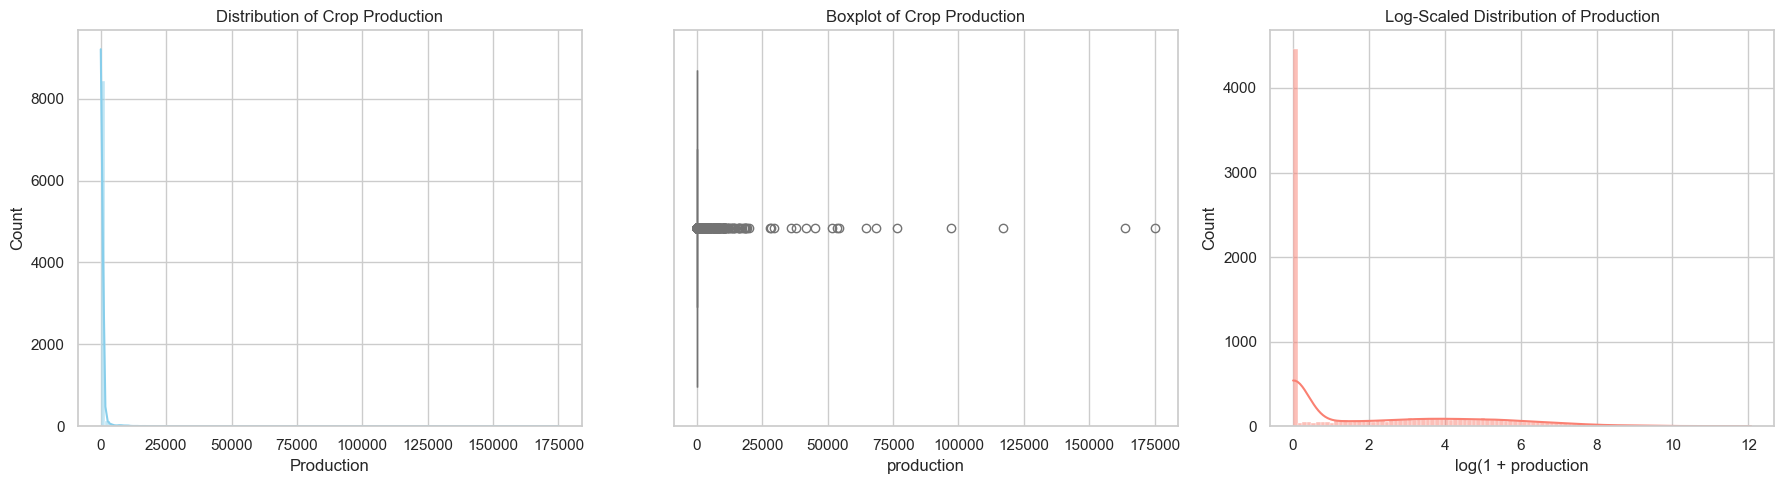

In [27]:
plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
sns.histplot(df['production'], bins=100, kde=True, color='skyblue')
plt.title('Distribution of Crop Production')
plt.xlabel('Production')
plt.ylabel('Count')

plt.subplot(1,3,2)
sns.boxplot(x=df['production'], color='lightgreen')
plt.title('Boxplot of Crop Production')

plt.subplot(1,3,3)
sns.histplot(np.log1p(df['production']), bins=100, kde=True, color='salmon')
plt.title('Log-Scaled Distribution of Production')
plt.xlabel('log(1 + production')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Environmental and Geographic Features Overview

Summary statistics of environmental and geographic features:


,temperature,precipitation,humidity,wind_speed,surface_soil_wetness,solar_radiation
count,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000,8685.000000
mean,25.409001,11.091983,89.406102,1.443368,0.941093,13.003665
std,1.332363,8.817262,3.238907,1.137290,0.032604,3.695956
min,21.220000,0.260000,79.820000,0.030000,0.820000,4.620000
25%,24.750000,5.520000,87.290000,0.400000,0.920000,10.200000
50%,25.340000,8.570000,89.760000,1.350000,0.950000,14.200000
75%,26.440000,15.170000,91.860000,1.710000,0.960000,15.580000
max,27.920000,48.410000,95.250000,4.820000,0.990000,18.940000


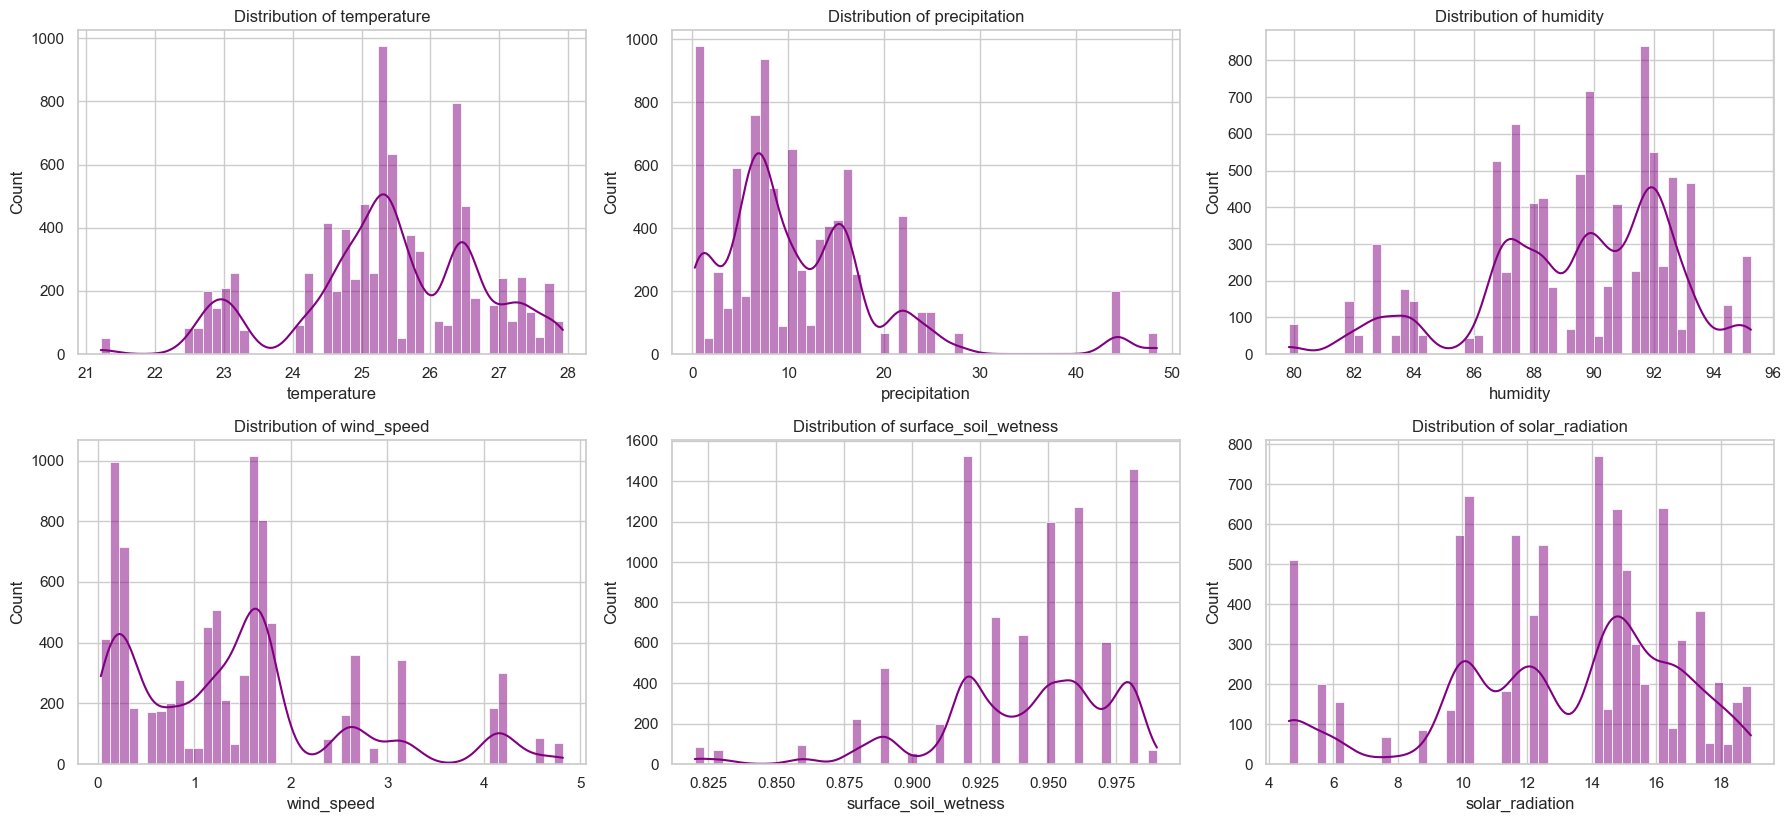

In [28]:
env_geo_features = ['temperature', 'precipitation', 'humidity',
    'wind_speed', 'surface_soil_wetness', 'solar_radiation']

print("Summary statistics of environmental and geographic features:")
display(df[env_geo_features].describe())

plt.figure(figsize=(18, 12))
for i, col in enumerate(env_geo_features, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], bins=50, kde=True, color='purple')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## Handling Imbalance and Zero Production

### Zero Production Analysis

Proportion of Zero Production Entries

In [29]:
zero_count = (df['production'] == 0).sum()
print(f"Number of zero-production entries: {zero_count} ({zero_count/len(df)*100:.2f}%)")

Number of zero-production entries: 4418 (50.87%)


Visualizing Zero vs Non-Zero Production Samples

In [30]:
import plotly.express as px

labels = ['Zero Production', 'Non-zero Production']
counts = [sum(df['production'] == 0), sum(df['production'] > 0)]

fig = px.pie(values=counts, names=labels, title='Production Distribution')
fig.show()

Filter out zero production rows for modeling

In [31]:
df_filtered = df[df['production'] > 0].copy()
print(f"Shape after filtering zero production: {df_filtered.shape}")

Shape after filtering zero production: (4267, 11)


## Feature Relationships and Correlation

### Correlation Matrix Heatmap

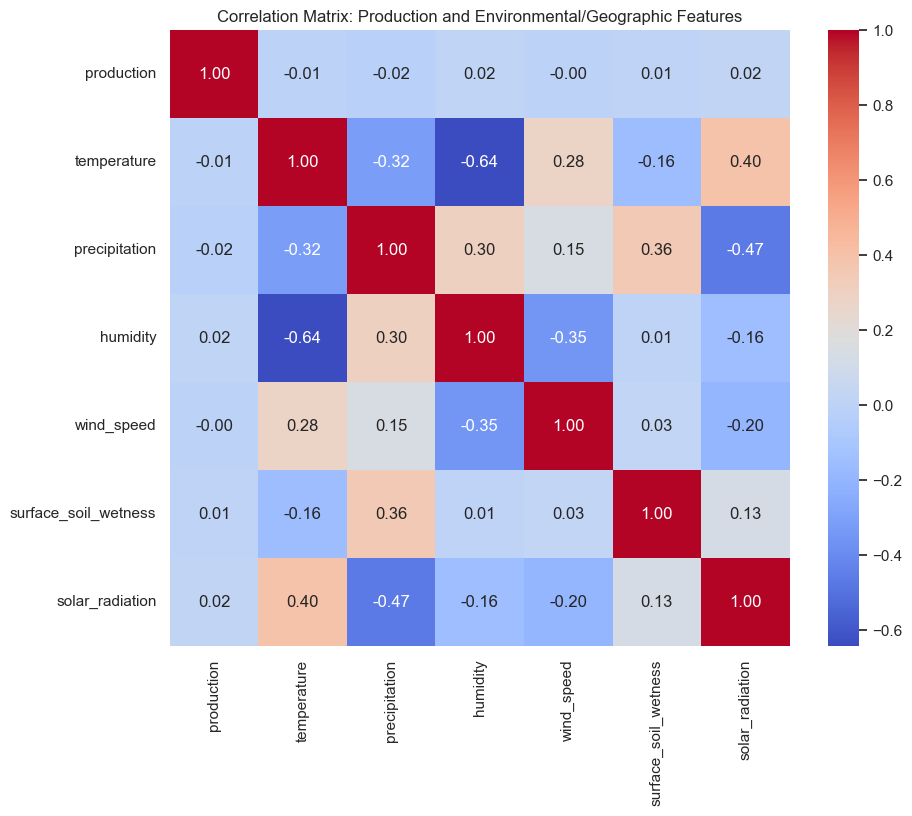

In [32]:
plt.figure(figsize=(10,8))
corr = df[['production'] + env_geo_features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix: Production and Environmental/Geographic Features')
plt.show()

### Scatter Plots with Target Variable

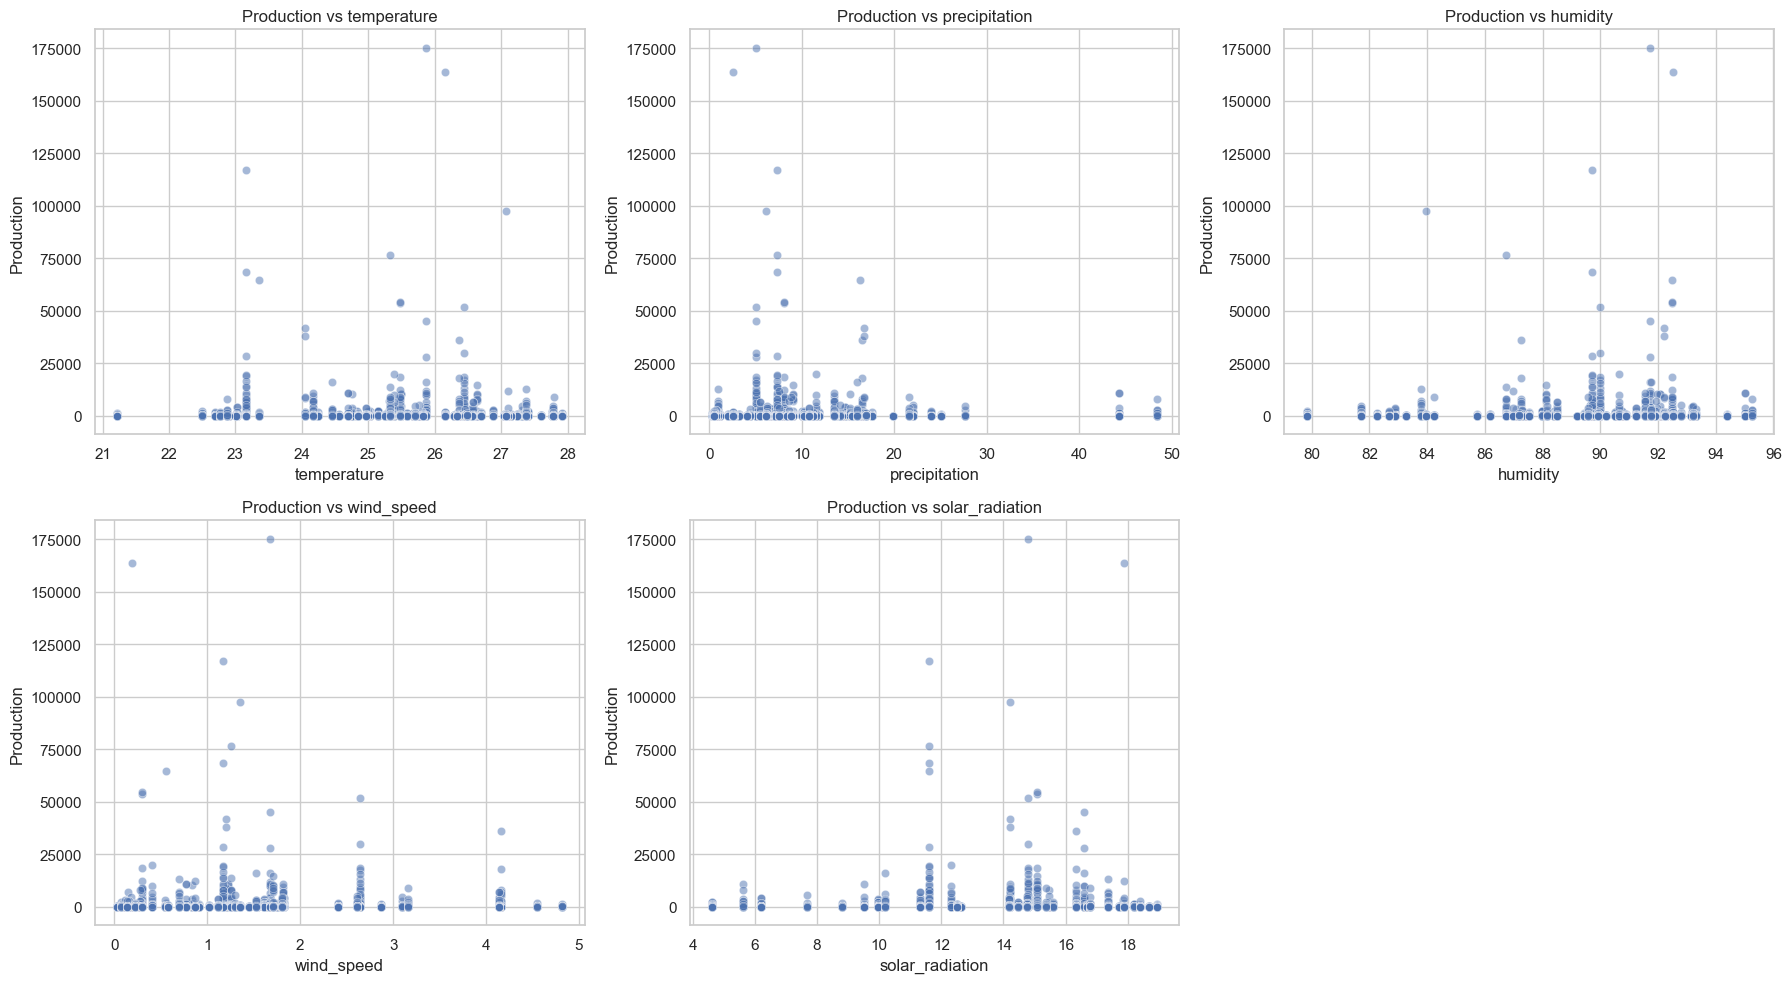

In [33]:
features = [
    'temperature', 'precipitation', 'humidity',
    'wind_speed', 'solar_radiation'
]
target = 'production'

# Set up the subplot grid
rows, cols = 2, 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 10))
axes = axes.flatten()

# Create scatter plots
for i, feature in enumerate(features):
    sns.scatterplot(
        data=df, x=feature, y=target, ax=axes[i], alpha=0.5
    )
    axes[i].set_title(f'Production vs {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Production')

# Hide any unused subplots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Boxplot of Crop Production by Crop Species

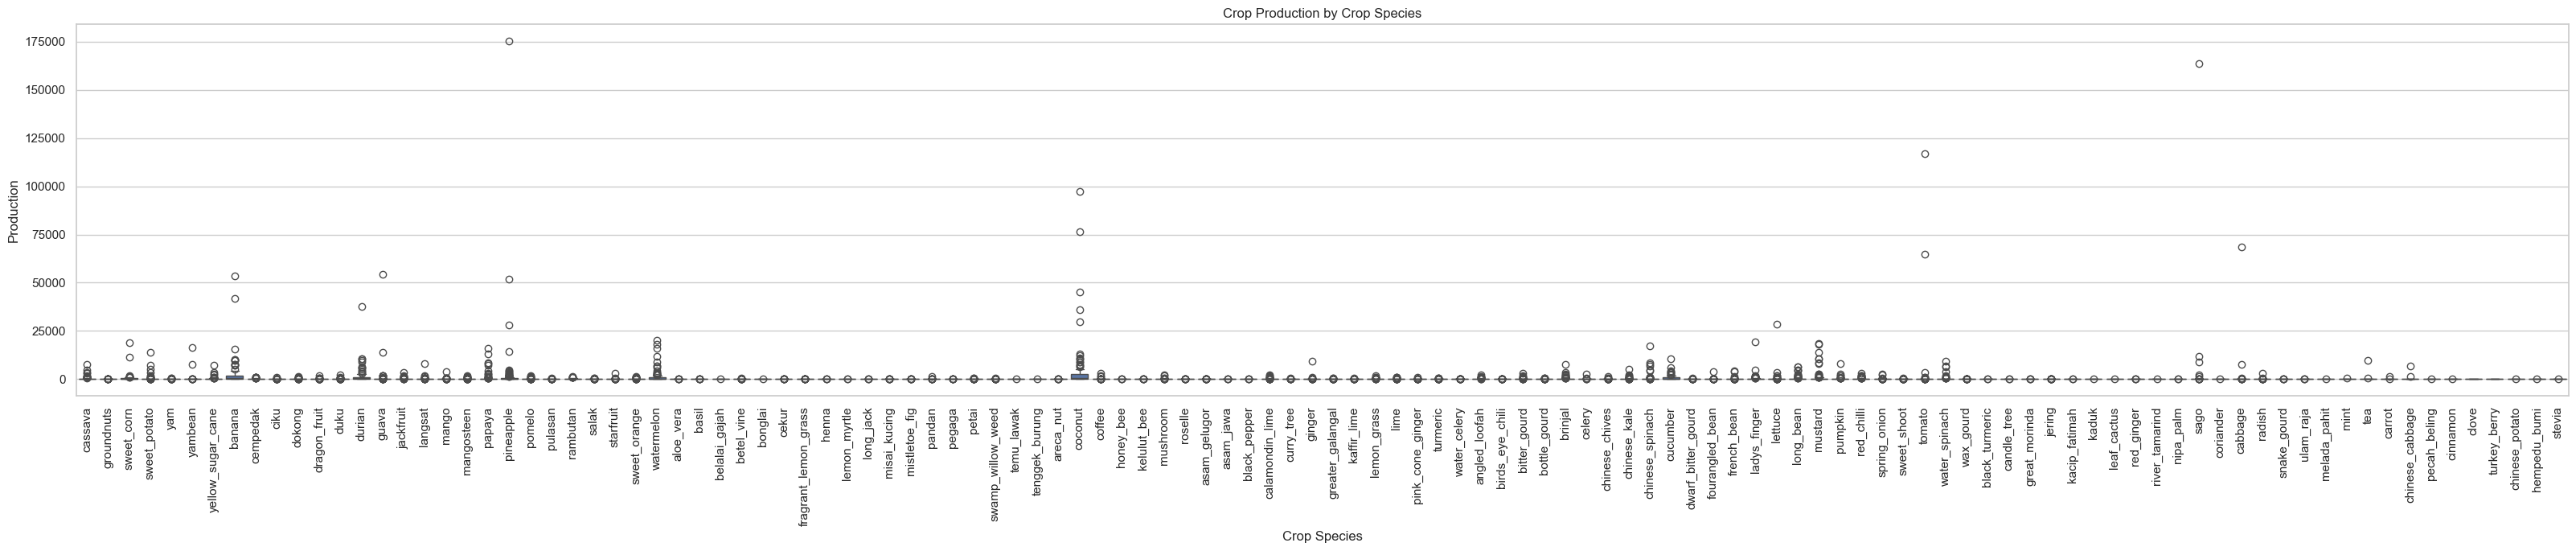

In [34]:
plt.figure(figsize=(40, 6))
sns.boxplot(data=df, x='crop_species', y='production')
plt.xticks(rotation=90)
plt.title('Crop Production by Crop Species')
plt.xlabel('Crop Species')
plt.ylabel('Production')
plt.show()

## Categorical Feature Analysis

### Top Categories by Production

Top 10 districts by mean production

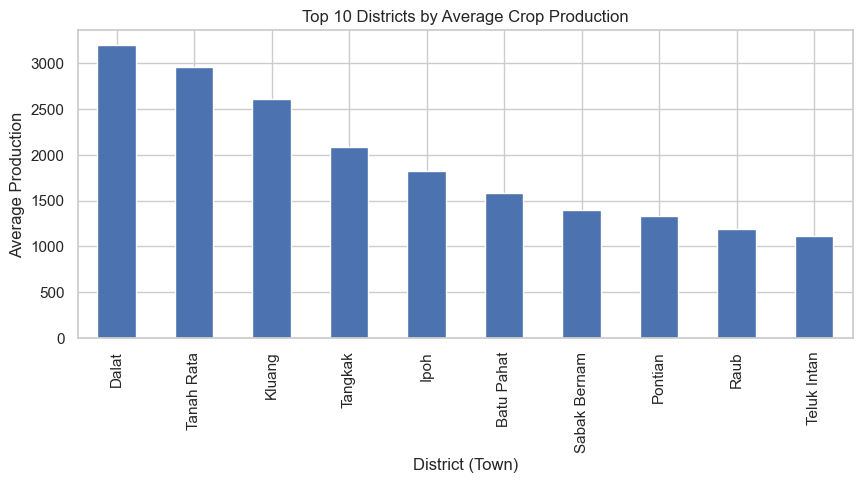

In [35]:
df.groupby('town')['production'].mean().sort_values(ascending=False).head(10).plot(
    kind='bar', figsize=(10, 4), title='Top 10 Districts by Average Crop Production'
)
plt.ylabel('Average Production')
plt.xlabel('District (Town)')
plt.show()

Crop species with highest average production

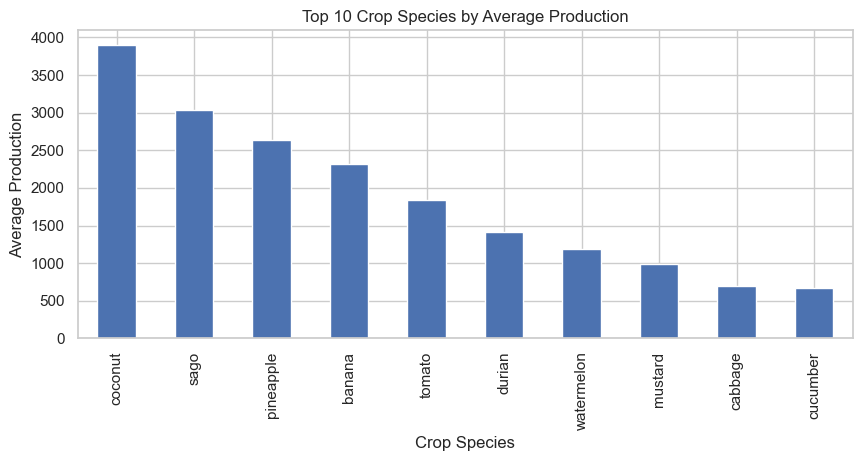

In [36]:
df.groupby('crop_species')['production'].mean().sort_values(ascending=False).head(10).plot(
    kind='bar', figsize=(10, 4), title='Top 10 Crop Species by Average Production'
)
plt.ylabel('Average Production')
plt.xlabel('Crop Species')
plt.show()

## Summary and Insights

## Normalization

In [37]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

### A. Min-Max Scaling (Normalization)

In [38]:
minmax_scaler = MinMaxScaler()
df_minmax = df.copy()
columns_to_normalize = [
    'temperature',
    'precipitation',
    'humidity',
    'wind_speed',
    'surface_soil_wetness',
    'solar_radiation'
]
df_minmax[columns_to_normalize] = minmax_scaler.fit_transform(df_minmax[columns_to_normalize])

In [39]:
df_minmax.info

<bound method DataFrame.info of            state   crop_type   crop_species  production               town  \
0          johor  cash_crops        cassava    920.5000         Batu Pahat   
1          johor  cash_crops     groundnuts      0.0000         Batu Pahat   
2          johor  cash_crops     sweet_corn      0.0000         Batu Pahat   
3          johor  cash_crops   sweet_potato    350.0000         Batu Pahat   
4          johor  cash_crops            yam    395.4000         Batu Pahat   
...          ...         ...            ...         ...                ...   
8680  terengganu   vegetable        mustard      3.6700  Bandar Permaisuri   
8681  terengganu   vegetable        pumpkin   2793.1500  Bandar Permaisuri   
8682  terengganu   vegetable         radish      3.8580  Bandar Permaisuri   
8683  terengganu   vegetable     red_chilli    451.9600  Bandar Permaisuri   
8684  terengganu   vegetable  water_spinach     11.0823  Bandar Permaisuri   

      temperature  precipitatio

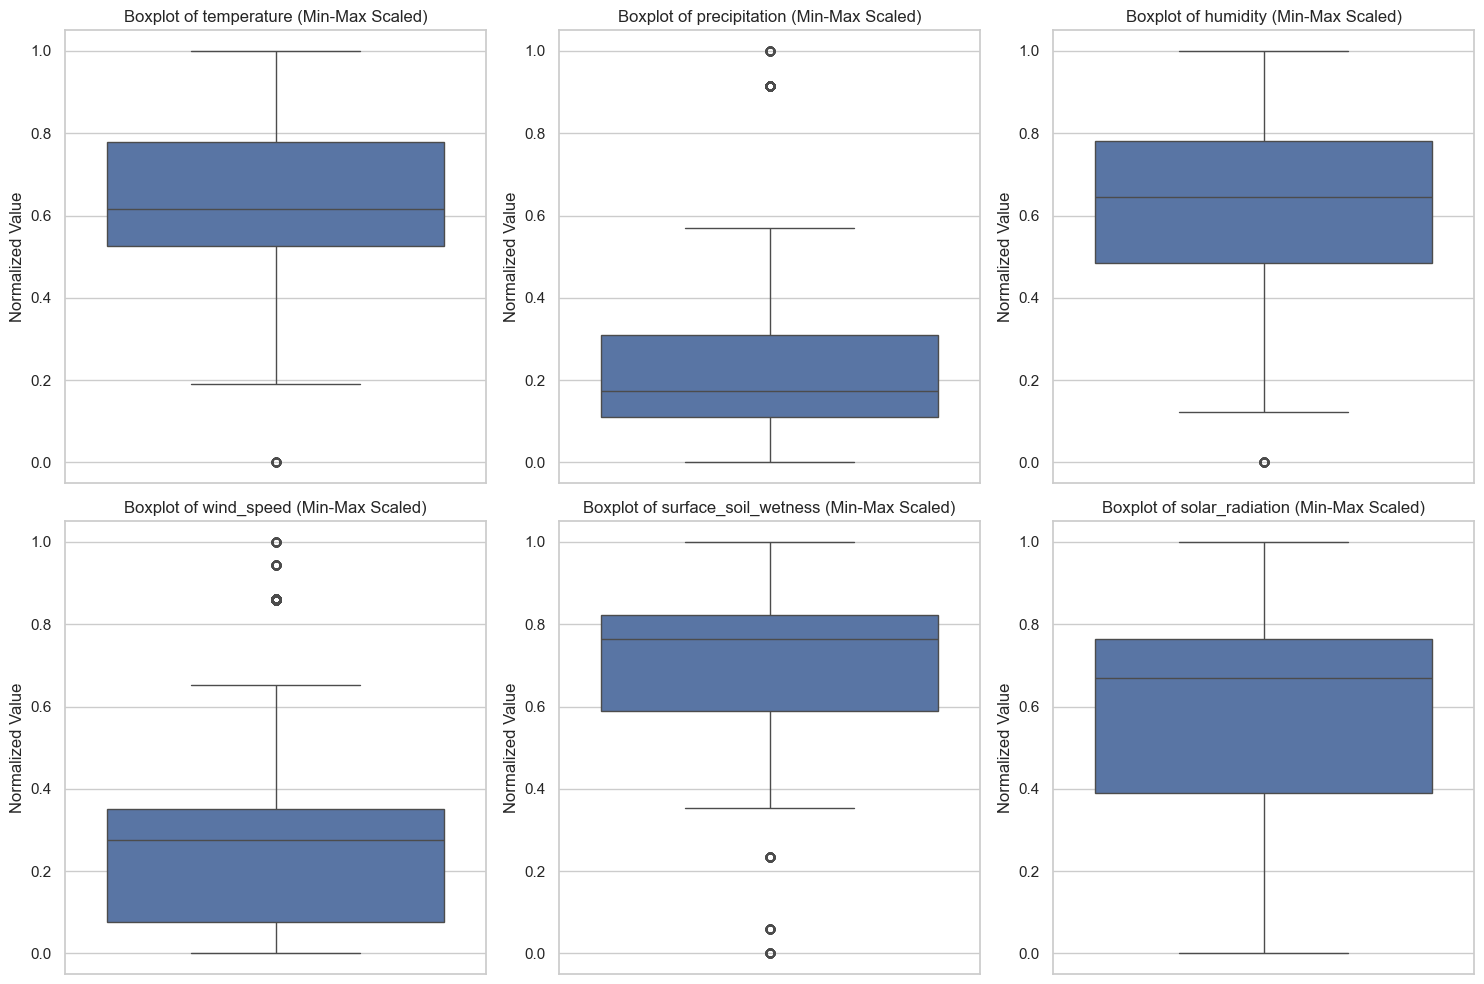

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = (len(columns_to_normalize) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

for i, col in enumerate(columns_to_normalize):
    ax = axes.flatten()[i]
    sns.boxplot(y=df_minmax[col], ax=ax)
    ax.set_title(f'Boxplot of {col} (Min-Max Scaled)')
    ax.set_ylabel('Normalized Value')

# Hide any unused subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

### B. Standardization (Z-score)

In [41]:
standard_scaler = StandardScaler()
df_standard = df.copy()
df_standard[columns_to_normalize] = standard_scaler.fit_transform(df_standard[columns_to_normalize])

In [42]:
df_standard.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8685 entries, 0 to 8684
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   state                 8685 non-null   object 
 1   crop_type             8685 non-null   object 
 2   crop_species          8685 non-null   object 
 3   production            8685 non-null   float64
 4   town                  8685 non-null   object 
 5   temperature           8685 non-null   float64
 6   precipitation         8685 non-null   float64
 7   humidity              8685 non-null   float64
 8   wind_speed            8685 non-null   float64
 9   surface_soil_wetness  8685 non-null   float64
 10  solar_radiation       8685 non-null   float64
dtypes: float64(7), object(4)
memory usage: 746.5+ KB


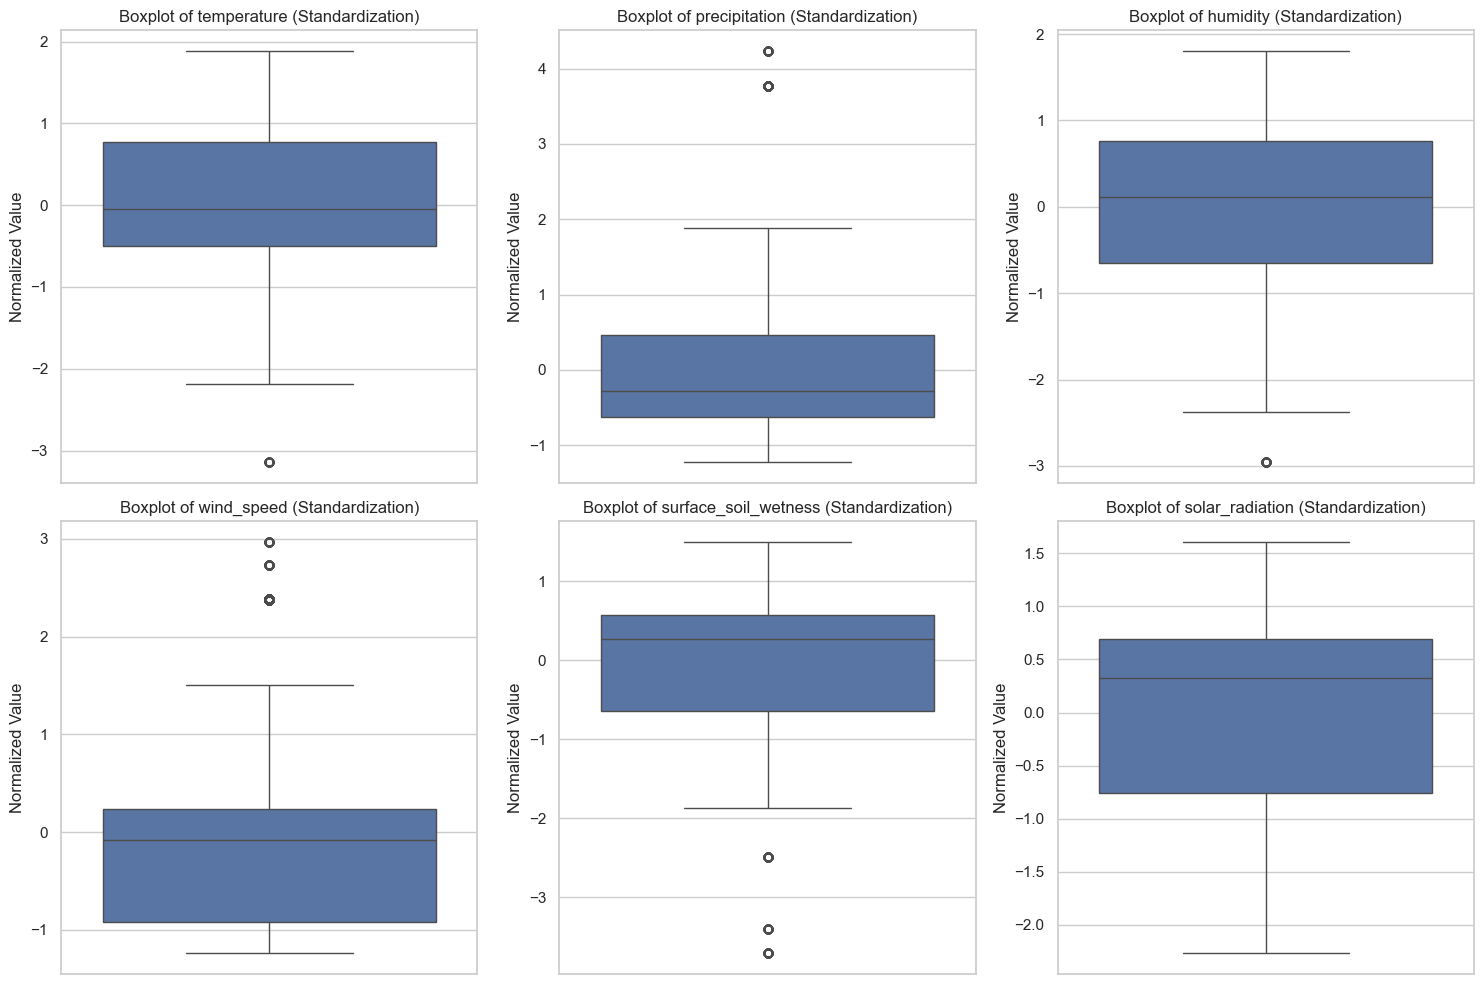

In [43]:
n_cols = 3
n_rows = (len(columns_to_normalize) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

for i, col in enumerate(columns_to_normalize):
    ax = axes.flatten()[i]
    sns.boxplot(y=df_standard[col], ax=ax)
    ax.set_title(f'Boxplot of {col} (Standardization)')
    ax.set_ylabel('Normalized Value')

# Hide any unused subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

### C. Robust Scaling

In [44]:
robust_scaler = RobustScaler()
df_robust = df.copy()
df_robust[columns_to_normalize] = robust_scaler.fit_transform(df_robust[columns_to_normalize])

In [45]:
df_robust.info

<bound method DataFrame.info of            state   crop_type   crop_species  production               town  \
0          johor  cash_crops        cassava    920.5000         Batu Pahat   
1          johor  cash_crops     groundnuts      0.0000         Batu Pahat   
2          johor  cash_crops     sweet_corn      0.0000         Batu Pahat   
3          johor  cash_crops   sweet_potato    350.0000         Batu Pahat   
4          johor  cash_crops            yam    395.4000         Batu Pahat   
...          ...         ...            ...         ...                ...   
8680  terengganu   vegetable        mustard      3.6700  Bandar Permaisuri   
8681  terengganu   vegetable        pumpkin   2793.1500  Bandar Permaisuri   
8682  terengganu   vegetable         radish      3.8580  Bandar Permaisuri   
8683  terengganu   vegetable     red_chilli    451.9600  Bandar Permaisuri   
8684  terengganu   vegetable  water_spinach     11.0823  Bandar Permaisuri   

      temperature  precipitatio

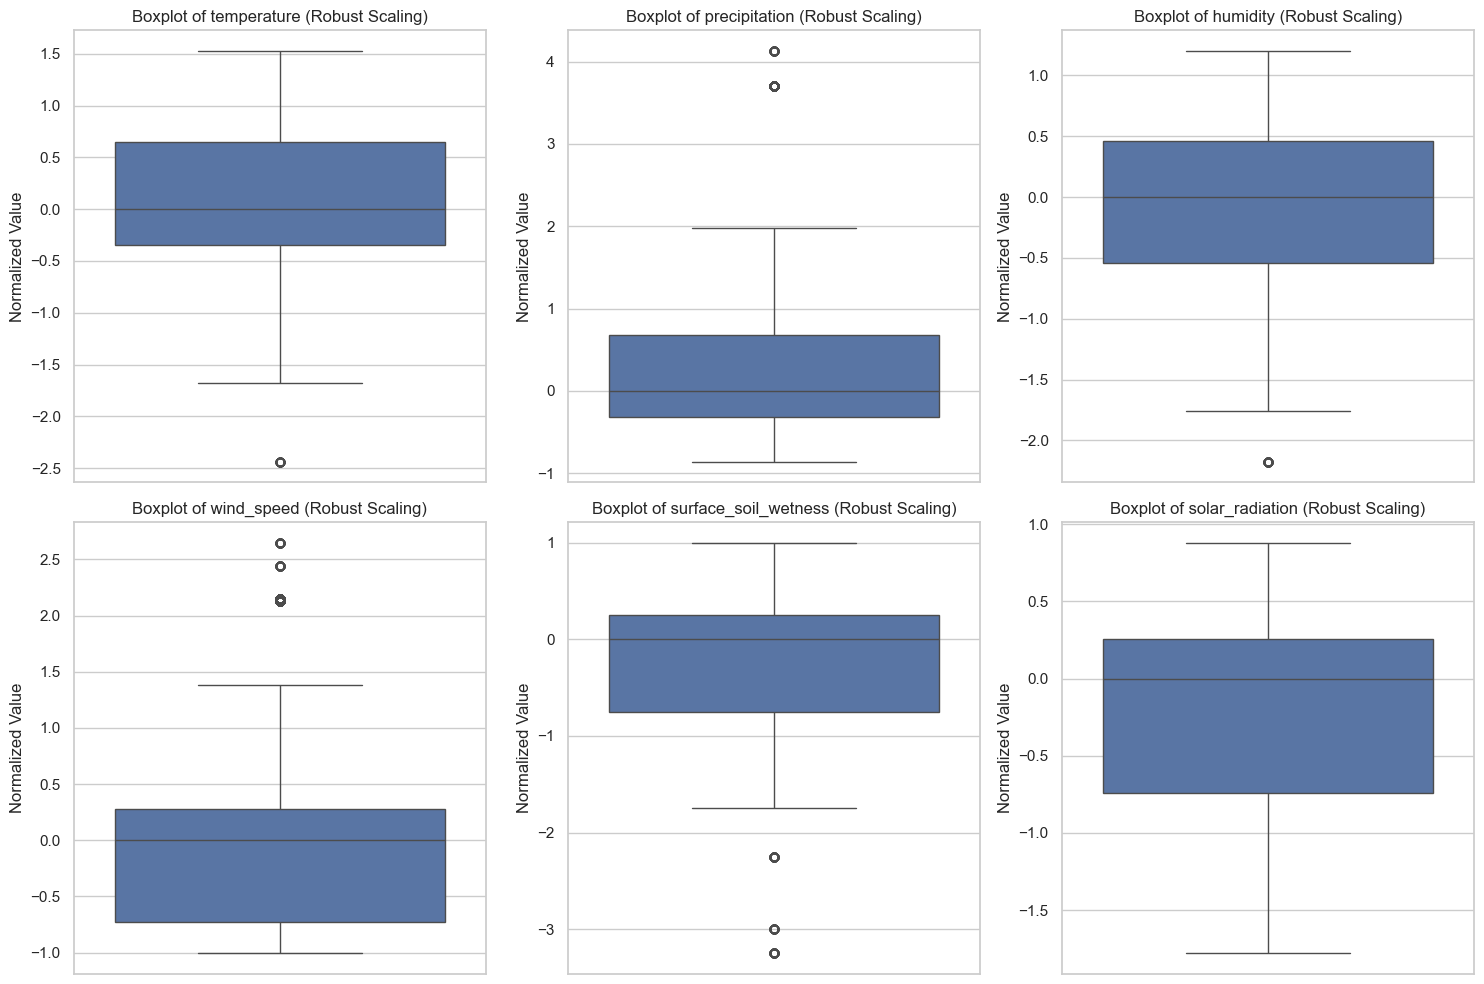

In [46]:
n_cols = 3
n_rows = (len(columns_to_normalize) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

for i, col in enumerate(columns_to_normalize):
    ax = axes.flatten()[i]
    sns.boxplot(y=df_robust[col], ax=ax)
    ax.set_title(f'Boxplot of {col} (Robust Scaling)')
    ax.set_ylabel('Normalized Value')

# Hide any unused subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes.flatten()[j])

plt.tight_layout()
plt.show()

## Transformation

In [47]:
rename_dict = {
    'temperature': 'Temperature (°C)',
    'precipitation': 'Precipitation (mm)',
    'humidity': 'Humidity (%)',
    'wind_speed': 'Wind Speed (m/s)',
    'surface_soil_wetness': 'Surface Soil Wetness',
    'solar_radiation': 'Solar Radiation (MJ/m²)',
    'production': 'Production (tonnes)',
    'state' : 'State',
    'crop_type' : 'Crop_type',
    'crop_species' : 'Crop_species'
}

for d in [df_minmax, df_standard, df_robust, df]:
    d.rename(columns=rename_dict) 
print(df_minmax.columns)
print(df_standard.columns)
print(df_robust.columns)

df.head()

Index(['state', 'crop_type', 'crop_species', 'production', 'town',
       'temperature', 'precipitation', 'humidity', 'wind_speed',
       'surface_soil_wetness', 'solar_radiation'],
      dtype='object')
Index(['state', 'crop_type', 'crop_species', 'production', 'town',
       'temperature', 'precipitation', 'humidity', 'wind_speed',
       'surface_soil_wetness', 'solar_radiation'],
      dtype='object')
Index(['state', 'crop_type', 'crop_species', 'production', 'town',
       'temperature', 'precipitation', 'humidity', 'wind_speed',
       'surface_soil_wetness', 'solar_radiation'],
      dtype='object')


,state,crop_type,crop_species,production,town,temperature,precipitation,humidity,wind_speed,surface_soil_wetness,solar_radiation
0,johor,cash_crops,cassava,920.5,Batu Pahat,25.87,5.03,91.72,1.67,0.92,16.59
1,johor,cash_crops,groundnuts,0.0,Batu Pahat,25.87,5.03,91.72,1.67,0.92,16.59
2,johor,cash_crops,sweet_corn,0.0,Batu Pahat,25.87,5.03,91.72,1.67,0.92,16.59
3,johor,cash_crops,sweet_potato,350.0,Batu Pahat,25.87,5.03,91.72,1.67,0.92,16.59
4,johor,cash_crops,yam,395.4,Batu Pahat,25.87,5.03,91.72,1.67,0.92,16.59


In [48]:
# FIXED QUICK FIX FOR POOR PERFORMANCE
# Handles categorical variables properly
# R² = 0.1252, RMSE = 2.1113 → Target: R² > 0.40, RMSE < 1.0

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import SelectKBest, f_regression
import xgboost as xgb
import lightgbm as lgb
from sklearn.ensemble import VotingRegressor

def fixed_quick_fix_poor_performance(df):
    """
    Fixed quick fix for poor model performance with categorical handling
    Targets: R² from 0.1252 to >0.40, RMSE from 2.1113 to <1.0
    """
    print("🛠️ FIXED QUICK FIX FOR POOR PERFORMANCE")
    print("   Current: R² = 0.1252, RMSE = 2.1113")
    print("   Target:  R² > 0.40,   RMSE < 1.0\n")
    
    # Step 0: Handle categorical variables first
    print("🔍 Step 0: Identifying and Handling Categorical Variables...")
    df_clean = df.copy()
    
    # Identify categorical columns
    categorical_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
    if 'production' in categorical_cols:
        categorical_cols.remove('production')
    
    print(f"   Found categorical columns: {categorical_cols}")
    
    # Handle categorical variables
    label_encoders = {}
    for col in categorical_cols:
        if col in df_clean.columns:
            print(f"   Encoding categorical column: {col}")
            le = LabelEncoder()
            df_clean[col + '_encoded'] = le.fit_transform(df_clean[col].astype(str))
            label_encoders[col] = le
            # Keep the encoded version, drop original
            df_clean = df_clean.drop(columns=[col])
    
    # Step 1: Aggressive outlier removal
    print("🧹 Step 1: Aggressive Data Cleaning...")
    
    # Get only numeric columns for outlier removal
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    outlier_cols = [col for col in ['production', 'temperature', 'precipitation', 'humidity', 'wind_speed'] 
                   if col in numeric_cols]
    
    print(f"   Checking outliers in: {outlier_cols}")
    
    # Remove extreme outliers (top/bottom 2.5%)
    for col in outlier_cols:
        Q1 = df_clean[col].quantile(0.025)
        Q99 = df_clean[col].quantile(0.975)
        df_clean = df_clean[(df_clean[col] >= Q1) & (df_clean[col] <= Q99)]
    
    print(f"   Removed outliers: {len(df)} → {len(df_clean)} samples ({len(df_clean)/len(df)*100:.1f}% retained)")
    
    # Step 2: Advanced Feature Engineering
    print("🔧 Step 2: Advanced Feature Engineering...")
    
    # Check if required columns exist
    required_cols = ['temperature', 'precipitation', 'humidity', 'wind_speed', 'surface_soil_wetness', 'solar_radiation']
    available_cols = [col for col in required_cols if col in df_clean.columns]
    print(f"   Available weather columns: {available_cols}")
    
    # Weather stress indicators (only if columns exist)
    if 'temperature' in df_clean.columns:
        df_clean['heat_stress'] = (df_clean['temperature'] > df_clean['temperature'].quantile(0.8)).astype(int)
        df_clean['optimal_temp'] = ((df_clean['temperature'] >= 18) & (df_clean['temperature'] <= 28)).astype(int)
        df_clean['temp_squared'] = df_clean['temperature'] ** 2
    
    if 'precipitation' in df_clean.columns:
        df_clean['drought_stress'] = (df_clean['precipitation'] < df_clean['precipitation'].quantile(0.2)).astype(int)
        df_clean['precip_log'] = np.log1p(df_clean['precipitation'])
    
    if 'humidity' in df_clean.columns:
        df_clean['optimal_humidity'] = ((df_clean['humidity'] >= 50) & (df_clean['humidity'] <= 80)).astype(int)
        df_clean['humidity_sqrt'] = np.sqrt(df_clean['humidity'])
    
    # Advanced weather indices (only if columns exist)
    if 'temperature' in df_clean.columns and 'humidity' in df_clean.columns:
        df_clean['heat_index'] = df_clean['temperature'] + (df_clean['humidity']/100) * 10
        df_clean['temp_humidity'] = df_clean['temperature'] * df_clean['humidity']
    
    if 'temperature' in df_clean.columns and 'precipitation' in df_clean.columns:
        df_clean['water_stress'] = df_clean['temperature'] / (df_clean['precipitation'] + 1)
    
    if all(col in df_clean.columns for col in ['temperature', 'surface_soil_wetness', 'solar_radiation']):
        df_clean['growing_index'] = (df_clean['temperature'] * df_clean['surface_soil_wetness'] * df_clean['solar_radiation']) / 1000
    
    if 'temperature' in df_clean.columns and 'wind_speed' in df_clean.columns:
        df_clean['wind_chill'] = df_clean['temperature'] - df_clean['wind_speed'] * 0.5
    
    if 'precipitation' in df_clean.columns and 'solar_radiation' in df_clean.columns:
        df_clean['precip_solar'] = df_clean['precipitation'] * df_clean['solar_radiation']
    
    if 'surface_soil_wetness' in df_clean.columns and 'temperature' in df_clean.columns:
        df_clean['soil_temp'] = df_clean['surface_soil_wetness'] * df_clean['temperature']
    
    print(f"   Created {len(df_clean.columns) - len(df.columns)} new features")
    
    # Step 3: Optimal target transformation
    print("🎯 Step 3: Optimizing Target Transformation...")
    
    # Test different transformations
    transformations = {
        'log': np.log1p(df_clean['production']),
        'sqrt': np.sqrt(df_clean['production']),
        'cbrt': np.cbrt(df_clean['production']),
        'original': df_clean['production']
    }
    
    # Quick test with available basic features
    basic_features = [col for col in required_cols if col in df_clean.columns]
    print(f"   Using basic features for transformation test: {basic_features}")
    
    if len(basic_features) >= 3:  # Need at least 3 features for meaningful test
        X_basic = df_clean[basic_features]
        
        best_transform = 'log'
        best_score = -1
        
        for name, y_transform in transformations.items():
            try:
                rf_quick = RandomForestRegressor(n_estimators=50, random_state=42)
                rf_quick.fit(X_basic, y_transform)
                score = rf_quick.score(X_basic, y_transform)
                print(f"   {name}: R² = {score:.4f}")
                if score > best_score:
                    best_score = score
                    best_transform = name
            except Exception as e:
                print(f"   {name}: Failed - {e}")
        
        y_optimal = transformations[best_transform]
        print(f"   ✅ Best transformation: {best_transform}")
    else:
        print("   ⚠️ Not enough features for transformation test, using log")
        y_optimal = transformations['log']
        best_transform = 'log'
    
    # Step 4: Smart feature selection
    print("📊 Step 4: Smart Feature Selection...")
    
    # All engineered features (excluding production and non-numeric)
    feature_columns = [col for col in df_clean.columns if col != 'production']
    
    # Ensure all feature columns are numeric
    X_all = df_clean[feature_columns].select_dtypes(include=[np.number])
    
    # Handle missing values with median for numeric columns
    X_all = X_all.fillna(X_all.median())
    
    print(f"   Working with {X_all.shape[1]} numeric features")
    
    # Remove highly correlated features
    if X_all.shape[1] > 1:
        corr_matrix = X_all.corr().abs()
        upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        high_corr = [col for col in upper_tri.columns if any(upper_tri[col] > 0.95)]
        X_cleaned = X_all.drop(columns=high_corr)
        print(f"   Removed {len(high_corr)} highly correlated features")
    else:
        X_cleaned = X_all
    
    # Select top features
    if X_cleaned.shape[1] > 0:
        k_features = min(20, X_cleaned.shape[1])
        selector = SelectKBest(score_func=f_regression, k=k_features)
        selector.fit(X_cleaned, y_optimal)
        selected_features = X_cleaned.columns[selector.get_support()].tolist()
        
        print(f"   Selected {len(selected_features)} features from {X_cleaned.shape[1]}")
        print(f"   Top 5: {selected_features[:5]}")
    else:
        print("   ⚠️ No features available after cleaning!")
        return None
    
    # Step 5: Advanced model training
    print("🤖 Step 5: Advanced Model Training...")
    
    # Prepare data
    X_final = X_cleaned[selected_features]
    X_train, X_test, y_train, y_test = train_test_split(X_final, y_optimal, test_size=0.2, random_state=42)
    
    # Scale features
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    models = {}
    
    # Optimized Random Forest
    print("   🌲 Training Random Forest...")
    rf_params = {
        'n_estimators': [200, 300],
        'max_depth': [15, 20],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 0.3]
    }
    rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params, cv=3, scoring='r2')
    rf_grid.fit(X_train_scaled, y_train)
    models['RandomForest'] = rf_grid.best_estimator_
    
    # Optimized XGBoost
    print("   🚀 Training XGBoost...")
    xgb_params = {
        'n_estimators': [200, 300],
        'learning_rate': [0.05, 0.1],
        'max_depth': [6, 8],
        'reg_alpha': [0.1, 1],
        'reg_lambda': [1, 2]
    }
    xgb_grid = GridSearchCV(xgb.XGBRegressor(random_state=42), xgb_params, cv=3, scoring='r2')
    xgb_grid.fit(X_train_scaled, y_train)
    models['XGBoost'] = xgb_grid.best_estimator_
    
    # LightGBM
    print("   💡 Training LightGBM...")
    lgb_model = lgb.LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=10,
        num_leaves=31,
        random_state=42,
        verbose=-1
    )
    lgb_model.fit(X_train_scaled, y_train)
    models['LightGBM'] = lgb_model
    
    # Ensemble
    print("   🎭 Creating Ensemble...")
    ensemble = VotingRegressor([
        ('rf', models['RandomForest']),
        ('xgb', models['XGBoost']),
        ('lgb', models['LightGBM'])
    ])
    ensemble.fit(X_train_scaled, y_train)
    models['Ensemble'] = ensemble
    
    # Step 6: Evaluation
    print("📊 Step 6: Model Evaluation...")
    
    results = []
    original_r2 = 0.1252
    original_rmse = 2.1113
    
    for name, model in models.items():
        y_pred = model.predict(X_test_scaled)
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        r2_improvement = ((r2 - original_r2) / abs(original_r2)) * 100
        rmse_improvement = ((original_rmse - rmse) / original_rmse) * 100
        
        results.append({
            'Model': name,
            'R²': r2,
            'RMSE': rmse,
            'R²_Improvement_%': r2_improvement,
            'RMSE_Improvement_%': rmse_improvement
        })
        
        print(f"   {name:12} | R²: {r2:.4f} ({r2_improvement:+.0f}%) | RMSE: {rmse:.4f} ({rmse_improvement:+.0f}%)")
    
    results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
    
    # Final summary
    best_model = results_df.iloc[0]
    print(f"\n🎉 IMPROVEMENT SUMMARY:")
    print(f"   Best Model: {best_model['Model']}")
    print(f"   R² Improvement: 0.1252 → {best_model['R²']:.4f} ({best_model['R²_Improvement_%']:+.0f}%)")
    print(f"   RMSE Improvement: 2.1113 → {best_model['RMSE']:.4f} ({best_model['RMSE_Improvement_%']:+.0f}%)")
    
    if best_model['R²'] > 0.40:
        print("   🎯 SUCCESS: Achieved R² > 0.40!")
    if best_model['RMSE'] < 1.0:
        print("   🎯 SUCCESS: Achieved RMSE < 1.0!")
    
    return results_df, models, selected_features, label_encoders

# =============================================================================
# SIMPLE USAGE FOR YOUR NOTEBOOK:
# results, models, features, encoders = fixed_quick_fix_poor_performance(df)
# ============================================================================= 

In [49]:
# Run the quick fix
results_df, models, selected_features, label_encoders = fixed_quick_fix_poor_performance(df)

# Display detailed results table
print("📊 MODEL PERFORMANCE COMPARISON TABLE:")
print("="*80)
print(results_df.to_string(index=False))

print("\n" + "="*80)

# Display formatted table with better alignment
print("📈 FORMATTED RESULTS:")
print(f"{'Model':<15} {'R²':<8} {'RMSE':<8} {'R² Improve':<12} {'RMSE Improve':<12}")
print("-" * 65)
for _, row in results_df.iterrows():
    print(f"{row['Model']:<15} {row['R²']:<8.4f} {row['RMSE']:<8.4f} {row['R²_Improvement_%']:<12.1f}% {row['RMSE_Improvement_%']:<12.1f}%")

print("\n" + "="*80)

# Highlight the best model
best_model = results_df.iloc[0]
print("🏆 BEST PERFORMING MODEL:")
print(f"   Model: {best_model['Model']}")
print(f"   R²: {best_model['R²']:.4f} (Original: 0.1252)")
print(f"   RMSE: {best_model['RMSE']:.4f} (Original: 2.1113)")
print(f"   R² Improvement: {best_model['R²_Improvement_%']:+.1f}%")
print(f"   RMSE Improvement: {best_model['RMSE_Improvement_%']:+.1f}%")

🛠️ FIXED QUICK FIX FOR POOR PERFORMANCE
   Current: R² = 0.1252, RMSE = 2.1113
   Target:  R² > 0.40,   RMSE < 1.0

🔍 Step 0: Identifying and Handling Categorical Variables...
   Found categorical columns: ['state', 'crop_type', 'crop_species', 'town']
   Encoding categorical column: state
   Encoding categorical column: crop_type
   Encoding categorical column: crop_species
   Encoding categorical column: town
🧹 Step 1: Aggressive Data Cleaning...
   Checking outliers in: ['production', 'temperature', 'precipitation', 'humidity', 'wind_speed']
   Removed outliers: 8685 → 7389 samples (85.1% retained)
🔧 Step 2: Advanced Feature Engineering...
   Available weather columns: ['temperature', 'precipitation', 'humidity', 'wind_speed', 'surface_soil_wetness', 'solar_radiation']
   Created 14 new features
🎯 Step 3: Optimizing Target Transformation...
   Using basic features for transformation test: ['temperature', 'precipitation', 'humidity', 'wind_speed', 'surface_soil_wetness', 'solar_radia

# Model Selection

#### In this project, the goal is to predict crop production based on environmental and geographic features. Since the target variable (production) is continuous, this is a regression problem. Several machine learning models were considered for this task, each with its own strengths and weaknesses

After exploring and processed the from the datasets we used

Now we use multiple models to test which model could perform the better

Here are the Machine Learning Models that we are going to test:

In [59]:
X_df = df.drop(['production'], axis=1)

In [60]:
x = df[X_df.columns]
y = df['production']

In [61]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [55]:
pip install lazypredict

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached cachetools-5.5.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_types-0.7.0-py3-none-any.whl.metadata (15 kB)
  Using cached pyasn1-0.6.1-py3-none-any.whl.metadata (8.4 kB)
   ---------------------------------------- 0.0/29.0 MB ? eta -:--:--
    --------------------------------------- 0.5/29.0 MB 3.4 MB/s eta 0:00:09
   -- ------------------------------------- 1.6/29.0 MB 4.2 MB/s eta 0:00:07
   ---- ----------------------------------- 3.1/29.0 MB 5.3 MB/s eta 0:00:05
   ------- -------------------------------- 5.2/29.0 MB 6.6 MB/s eta 0:00:04
   ----------- ---------------------------- 8.1/29.0 MB 8.1 MB/s eta 0:00:03
   ---------------- ----------------------- 12.3/29.0 MB 10.2 MB/s eta 0:00:02
   ------------------------ --------------- 17.8/29.0 MB 12.5 MB/s e

In [66]:
from lazypredict.Supervised import LazyRegressor
from sklearn.utils import all_estimators
from sklearn.base import RegressorMixin
from sklearn.model_selection import learning_curve

In [67]:
chosen_regressors = [
    'RandomForestRegressor', 'BaggingRegressor', 'XGBRegressor',
    'GradientBoostingRegressor', 'AdaBoostRegressor', 'DecisionTreeRegressor',
    'SGDRegressor', 'LinearRegression', 'LassoCV', 'RidgeCV', 'BayesianRidge',
    'ElasticNetCV', 'SVR', 'PolynomialRegression'
]

REGRESSORS = [
    est for est in all_estimators()
    if (issubclass(est[1], RegressorMixin) and (est[0] in chosen_regressors))
]

In [68]:
reg = LazyRegressor(verbose=1,
                    ignore_warnings=False,
                    custom_metric=None,
                    regressors=REGRESSORS)
models, predictions = reg.fit(X_train, X_test, Y_train, Y_test)

'tuple' object has no attribute '__name__'
Invalid Regressor(s)


  0%|          | 0/12 [00:00<?, ?it/s]

{'Model': 'AdaBoostRegressor', 'R-Squared': -1.3013464151389234, 'Adjusted R-Squared': -1.3146798242648732, 'RMSE': 4050.000463215036, 'Time taken': 0.19166851043701172}
{'Model': 'BaggingRegressor', 'R-Squared': -0.7834892955446846, 'Adjusted R-Squared': -0.793822373734399, 'RMSE': 3565.326671586086, 'Time taken': 0.7310299873352051}
{'Model': 'BayesianRidge', 'R-Squared': -0.0009188064203158319, 'Adjusted R-Squared': -0.006717872506180944, 'RMSE': 2670.9361074558556, 'Time taken': 0.05316948890686035}
{'Model': 'DecisionTreeRegressor', 'R-Squared': -4.215133396104239, 'Adjusted R-Squared': -4.245348537448992, 'RMSE': 6096.727515997894, 'Time taken': 0.13125944137573242}
{'Model': 'ElasticNetCV', 'R-Squared': 0.00226892380236976, 'Adjusted R-Squared': -0.003511673394603898, 'RMSE': 2666.67951164214, 'Time taken': 0.16601037979125977}
{'Model': 'GradientBoostingRegressor', 'R-Squared': 0.016890036128100028, 'Adjusted R-Squared': 0.011194149894774963, 'RMSE': 2647.0681551021125, 'Time t

In [69]:
models

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
GradientBoostingRegressor,0.01,0.02,2647.07,1.15
LassoCV,0.00,0.01,2656.73,0.16
RidgeCV,-0.00,0.00,2663.28,0.06
LinearRegression,-0.00,0.00,2663.77,0.04
ElasticNetCV,-0.00,0.00,2666.68,0.17
BayesianRidge,-0.01,-0.00,2670.94,0.05
SVR,-0.02,-0.01,2685.74,3.66
BaggingRegressor,-0.79,-0.78,3565.33,0.73
RandomForestRegressor,-0.97,-0.95,3731.86,6.27
